In [15]:
# ============================================================
# BLOCK 1 — Install & Import Libraries
# ============================================================
!pip install -q imbalanced-learn scikit-learn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import pairwise
from imblearn.over_sampling import SMOTE
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [16]:
# ============================================================
# BLOCK 2 — Load Datasets
# ============================================================

train = pd.read_csv('fraudTrain.csv')
test  = pd.read_csv('fraudTest.csv')

print("=" * 60)
print("DATASETS LOADED")
print("=" * 60)
print(f"  Train shape : {train.shape}")
print(f"  Test  shape : {test.shape}")
print(f"\n  Train columns : {list(train.columns)}")
print("=" * 60)
print("\n✅ Datasets loaded successfully!")

DATASETS LOADED
  Train shape : (1296675, 23)
  Test  shape : (555719, 23)

  Train columns : ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

✅ Datasets loaded successfully!


In [17]:
# ============================================================
# BLOCK 3 — Drop Unnecessary Columns
# ============================================================

drop_cols = [
    'Unnamed: 0',   # index column
    'cc_num',       # credit card number (identity)
    'first',        # first name (identity)
    'last',         # last name (identity)
    'street',       # street address (identity)
    'trans_num',    # transaction ID (identity)
]

# Only drop columns that actually exist
drop_cols = [c for c in drop_cols if c in train.columns]

before_train = train.shape[1]
before_test  = test.shape[1]

train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

print("=" * 60)
print("UNNECESSARY COLUMNS DROPPED")
print("=" * 60)
print(f"  Columns dropped    : {drop_cols}")
print(f"  Train: {before_train} cols → {train.shape[1]} cols")
print(f"  Test : {before_test} cols  → {test.shape[1]} cols")
print(f"\n  Remaining columns ({train.shape[1]}):")
for col in train.columns:
    print(f"    → {col}")
print("=" * 60)
print("\n✅ Unnecessary columns dropped!")

UNNECESSARY COLUMNS DROPPED
  Columns dropped    : ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num']
  Train: 23 cols → 17 cols
  Test : 23 cols  → 17 cols

  Remaining columns (17):
    → trans_date_trans_time
    → merchant
    → category
    → amt
    → gender
    → city
    → state
    → zip
    → lat
    → long
    → city_pop
    → job
    → dob
    → unix_time
    → merch_lat
    → merch_long
    → is_fraud

✅ Unnecessary columns dropped!


In [18]:
# ============================================================
# BLOCK 4 — Feature Engineering
# ============================================================

def engineer_features(df):
    df = df.copy()

    # --- DateTime features ---
    df['trans_date_trans_time'] = pd.to_datetime(
        df['trans_date_trans_time'])
    df['hour']       = df['trans_date_trans_time'].dt.hour
    df['day']        = df['trans_date_trans_time'].dt.dayofweek
    df['month']      = df['trans_date_trans_time'].dt.month
    df['day_of_year']= df['trans_date_trans_time'].dt.dayofyear

    # --- Age from dob ---
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = (pd.to_datetime('today') - df['dob']).dt.days // 365

    # --- Distance between cardholder and merchant ---
    # Using Euclidean distance from lat/long
    df['distance'] = np.sqrt(
        (df['lat']       - df['merch_lat'])  ** 2 +
        (df['long']      - df['merch_long']) ** 2
    )

    # --- Drop columns no longer needed ---
    df = df.drop(columns=[
        'trans_date_trans_time',
        'dob',
        'unix_time',
        'merch_zipcode'
    ], errors='ignore')

    return df


train = engineer_features(train)
test  = engineer_features(test)

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print("  New features added:")
print("    ✅ hour        — hour of transaction (0-23)")
print("    ✅ day         — day of week (0=Mon, 6=Sun)")
print("    ✅ month       — month of transaction (1-12)")
print("    ✅ day_of_year — day number in year")
print("    ✅ age         — cardholder age")
print("    ✅ distance    — cardholder to merchant distance")
print(f"\n  Train shape now : {train.shape}")
print(f"  Test  shape now : {test.shape}")
print("=" * 60)
print("\n✅ Feature engineering done!")

FEATURE ENGINEERING COMPLETE
  New features added:
    ✅ hour        — hour of transaction (0-23)
    ✅ day         — day of week (0=Mon, 6=Sun)
    ✅ month       — month of transaction (1-12)
    ✅ day_of_year — day number in year
    ✅ age         — cardholder age
    ✅ distance    — cardholder to merchant distance

  Train shape now : (1296675, 20)
  Test  shape now : (555719, 20)

✅ Feature engineering done!


In [19]:
# ============================================================
# BLOCK 5 — Check Remaining Columns
# ============================================================

print("=" * 60)
print("CURRENT COLUMN OVERVIEW")
print("=" * 60)

for col in train.columns:
    dtype   = train[col].dtype
    nunique = train[col].nunique()
    sample  = train[col].iloc[0]
    print(f"  {col:<25} dtype={str(dtype):<12}"
          f"unique={nunique:<8} sample={sample}")

print("=" * 60)

CURRENT COLUMN OVERVIEW
  merchant                  dtype=object      unique=693      sample=fraud_Rippin, Kub and Mann
  category                  dtype=object      unique=14       sample=misc_net
  amt                       dtype=float64     unique=52928    sample=4.97
  gender                    dtype=object      unique=2        sample=F
  city                      dtype=object      unique=894      sample=Moravian Falls
  state                     dtype=object      unique=51       sample=NC
  zip                       dtype=int64       unique=970      sample=28654
  lat                       dtype=float64     unique=968      sample=36.0788
  long                      dtype=float64     unique=969      sample=-81.1781
  city_pop                  dtype=int64       unique=879      sample=3495
  job                       dtype=object      unique=494      sample=Psychologist, counselling
  merch_lat                 dtype=float64     unique=1247805  sample=36.011293
  merch_long           

In [20]:
# ============================================================
# BLOCK 5 — Check Remaining Columns
# ============================================================

print("=" * 60)
print("CURRENT COLUMN OVERVIEW")
print("=" * 60)

for col in train.columns:
    dtype   = train[col].dtype
    nunique = train[col].nunique()
    sample  = train[col].iloc[0]
    print(f"  {col:<25} dtype={str(dtype):<12}"
          f"unique={nunique:<8} sample={sample}")

print("=" * 60)


CURRENT COLUMN OVERVIEW
  merchant                  dtype=object      unique=693      sample=fraud_Rippin, Kub and Mann
  category                  dtype=object      unique=14       sample=misc_net
  amt                       dtype=float64     unique=52928    sample=4.97
  gender                    dtype=object      unique=2        sample=F
  city                      dtype=object      unique=894      sample=Moravian Falls
  state                     dtype=object      unique=51       sample=NC
  zip                       dtype=int64       unique=970      sample=28654
  lat                       dtype=float64     unique=968      sample=36.0788
  long                      dtype=float64     unique=969      sample=-81.1781
  city_pop                  dtype=int64       unique=879      sample=3495
  job                       dtype=object      unique=494      sample=Psychologist, counselling
  merch_lat                 dtype=float64     unique=1247805  sample=36.011293
  merch_long           

In [21]:
# ============================================================
# BLOCK 6 — Encode Categorical Columns (FIXED)
# ============================================================

from sklearn.preprocessing import LabelEncoder
import joblib
import os

# Create models folder first
os.makedirs('models', exist_ok=True)

# Find categorical columns automatically
cat_cols = train.select_dtypes(include='object').columns.tolist()

# Remove target column if present
for col_to_remove in ['is_fraud', 'trans_date_trans_time', 'dob']:
    if col_to_remove in cat_cols:
        cat_cols.remove(col_to_remove)

print("=" * 60)
print("ENCODING CATEGORICAL COLUMNS")
print("=" * 60)
print(f"  Categorical columns found: {cat_cols}")
print()

label_encoders = {}

for col in cat_cols:
    try:
        le = LabelEncoder()

        # Fill any nulls just in case
        train[col] = train[col].fillna('Unknown')
        test[col]  = test[col].fillna('Unknown')

        # Convert to string to avoid type issues
        train[col] = train[col].astype(str)
        test[col]  = test[col].astype(str)

        # Fit on combined train + test to avoid unseen label error
        combined = pd.concat(
            [train[col], test[col]], axis=0).unique()
        le.fit(combined)

        train[col] = le.transform(train[col])
        test[col]  = le.transform(test[col])

        label_encoders[col] = le
        print(f"  ✅ {col:<20} → "
              f"{len(le.classes_)} unique labels encoded")

    except Exception as e:
        print(f"  ❌ {col:<20} → ERROR: {e}")

# Save label encoders
joblib.dump(label_encoders, 'models/label_encoders.pkl')

print()
print("=" * 60)
print(f"  Total columns encoded : {len(label_encoders)}")
print(f"  Saved → models/label_encoders.pkl")
print("=" * 60)
print("\n✅ Encoding complete!")

ENCODING CATEGORICAL COLUMNS
  Categorical columns found: ['merchant', 'category', 'gender', 'city', 'state', 'job']

  ✅ merchant             → 693 unique labels encoded
  ✅ category             → 14 unique labels encoded
  ✅ gender               → 2 unique labels encoded
  ✅ city                 → 906 unique labels encoded
  ✅ state                → 51 unique labels encoded
  ✅ job                  → 497 unique labels encoded

  Total columns encoded : 6
  Saved → models/label_encoders.pkl

✅ Encoding complete!


In [22]:
# ============================================================
# BLOCK 7 — Scale amt Column
# ============================================================

scaler = StandardScaler()

# Fit ONLY on train — never fit on test
train['amt'] = scaler.fit_transform(train[['amt']])
test['amt']  = scaler.transform(test[['amt']])

print("=" * 60)
print("AMOUNT COLUMN SCALING")
print("=" * 60)
print(f"  Train amt — Mean: {train['amt'].mean():.6f}"
      f"  Std: {train['amt'].std():.6f}")
print(f"  Test  amt — Mean: {test['amt'].mean():.6f}"
      f"  Std: {test['amt'].std():.6f}")
print("=" * 60)
print("\n✅ Amount column scaled using StandardScaler!")

# Save scaler
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ Scaler saved → models/scaler.pkl")

AMOUNT COLUMN SCALING
  Train amt — Mean: 0.000000  Std: 1.000000
  Test  amt — Mean: -0.005977  Std: 0.977731

✅ Amount column scaled using StandardScaler!
✅ Scaler saved → models/scaler.pkl


In [23]:
# ============================================================
# BLOCK 8 — Separate Features and Target
# ============================================================

X_train = train.drop(columns=['is_fraud'])
y_train = train['is_fraud']

X_test  = test.drop(columns=['is_fraud'])
y_test  = test['is_fraud']

print("=" * 60)
print("FEATURES & TARGET SEPARATED")
print("=" * 60)
print(f"  X_train : {X_train.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")
print(f"\n  Features ({len(X_train.columns)}):")
for col in X_train.columns:
    print(f"    → {col}")
print("=" * 60)
print("\n✅ Features and target separated!")

FEATURES & TARGET SEPARATED
  X_train : (1296675, 19)
  y_train : (1296675,)
  X_test  : (555719, 19)
  y_test  : (555719,)

  Features (19):
    → merchant
    → category
    → amt
    → gender
    → city
    → state
    → zip
    → lat
    → long
    → city_pop
    → job
    → merch_lat
    → merch_long
    → hour
    → day
    → month
    → day_of_year
    → age
    → distance

✅ Features and target separated!


CLASS IMBALANCE — Before SMOTE
  Normal (0) : 1,289,169  (99.42%)
  Fraud  (1) : 7,506   (0.5789%)
  Ratio      : 171 : 1


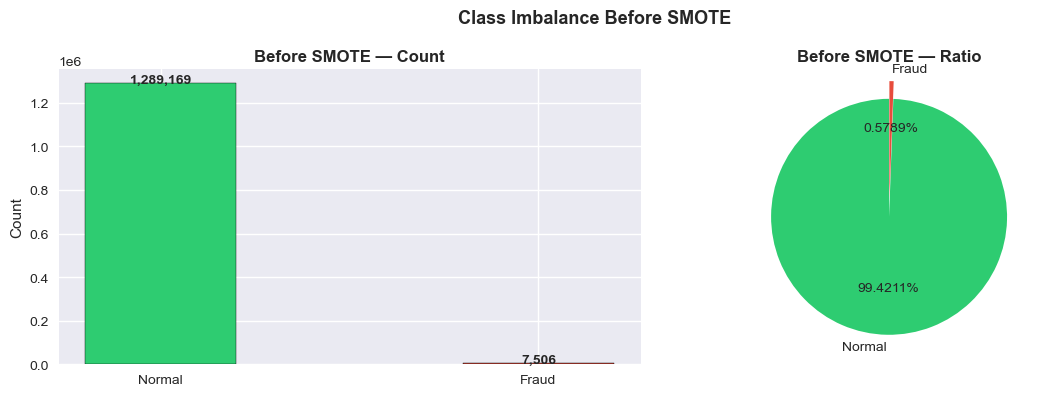


⚠️  Severe imbalance — Applying SMOTE now!


In [24]:
# ============================================================
# BLOCK 9 — Check Class Imbalance Before SMOTE
# ============================================================

fraud_count  = y_train.sum()
normal_count = (y_train == 0).sum()
total        = len(y_train)

print("=" * 60)
print("CLASS IMBALANCE — Before SMOTE")
print("=" * 60)
print(f"  Normal (0) : {normal_count:,}  ({normal_count/total*100:.2f}%)")
print(f"  Fraud  (1) : {fraud_count:,}   ({fraud_count/total*100:.4f}%)")
print(f"  Ratio      : {normal_count // fraud_count} : 1")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal', 'Fraud'],
            [normal_count, fraud_count],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black', width=0.4)
axes[0].set_title('Before SMOTE — Count',
                  fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([normal_count, fraud_count]):
    axes[0].text(i, v + 1000, f'{v:,}',
                 ha='center', fontweight='bold')

axes[1].pie([normal_count, fraud_count],
            labels=['Normal', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.4f%%',
            startangle=90,
            explode=(0, 0.15))
axes[1].set_title('Before SMOTE — Ratio',
                  fontweight='bold')

plt.suptitle('Class Imbalance Before SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️  Severe imbalance — Applying SMOTE now!")

In [25]:
# ============================================================
# BLOCK 10 — Apply SMOTE (Train Only)
# ============================================================

print("⏳ Applying SMOTE... (may take 2-3 minutes on large data)")

smote = SMOTE(
    sampling_strategy = 0.1,  # fraud = 10% of normal after SMOTE
    random_state      = 42,
    k_neighbors       = 5
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("=" * 60)
print("SMOTE APPLIED SUCCESSFULLY")
print("=" * 60)
print(f"  Before SMOTE — Train samples : {len(X_train):,}")
print(f"  After  SMOTE — Train samples : {len(X_train_sm):,}")
print(f"\n  Normal (0) : {(y_train_sm==0).sum():,}")
print(f"  Fraud  (1) : {(y_train_sm==1).sum():,}")
print(f"  New ratio  : {(y_train_sm==0).sum() // (y_train_sm==1).sum()} : 1")
print("=" * 60)
print("\n✅ SMOTE applied — Test set is NOT touched!")

⏳ Applying SMOTE... (may take 2-3 minutes on large data)
SMOTE APPLIED SUCCESSFULLY
  Before SMOTE — Train samples : 1,296,675
  After  SMOTE — Train samples : 1,418,085

  Normal (0) : 1,289,169
  Fraud  (1) : 128,916
  New ratio  : 10 : 1

✅ SMOTE applied — Test set is NOT touched!


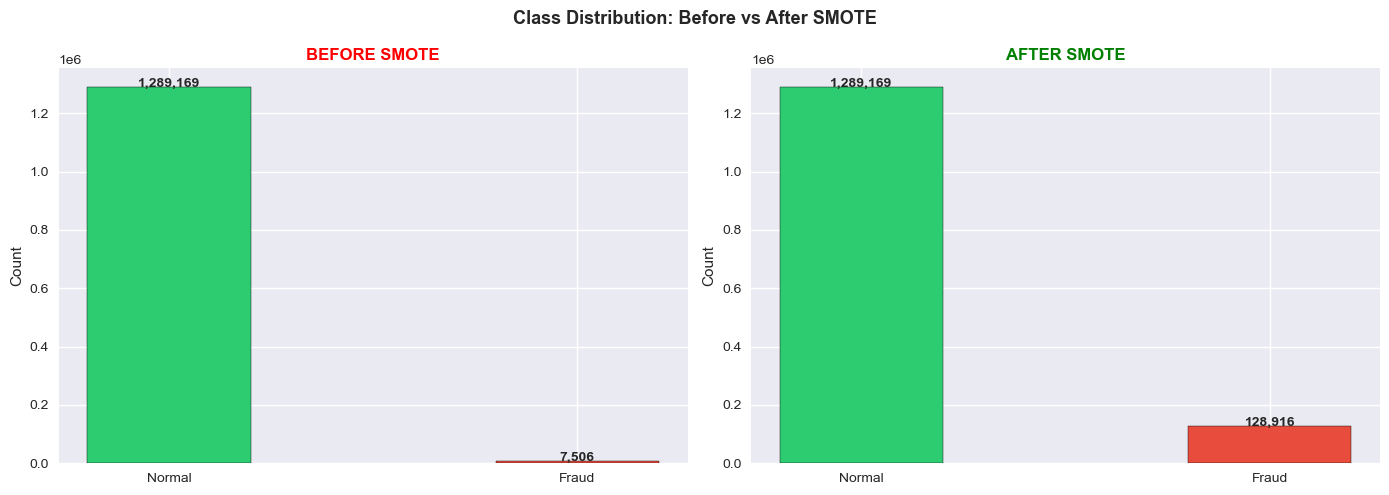

VERIFICATION SUMMARY
  Normal : 1,289,169
  Fraud  : 128,916
  Ratio  : 10 : 1

✅ Data balanced and verified!


In [26]:
# ============================================================
# BLOCK 11 — Verify Balanced Data After SMOTE
# ============================================================

normal_after = (y_train_sm == 0).sum()
fraud_after  = (y_train_sm == 1).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].bar(['Normal', 'Fraud'],
            [normal_count, fraud_count],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black', width=0.4)
axes[0].set_title('BEFORE SMOTE',
                  fontweight='bold', color='red')
axes[0].set_ylabel('Count')
for i, v in enumerate([normal_count, fraud_count]):
    axes[0].text(i, v + 500, f'{v:,}',
                 ha='center', fontweight='bold')

# After
axes[1].bar(['Normal', 'Fraud'],
            [normal_after, fraud_after],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black', width=0.4)
axes[1].set_title('AFTER SMOTE',
                  fontweight='bold', color='green')
axes[1].set_ylabel('Count')
for i, v in enumerate([normal_after, fraud_after]):
    axes[1].text(i, v + 500, f'{v:,}',
                 ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 60)
print("VERIFICATION SUMMARY")
print("=" * 60)
print(f"  Normal : {normal_after:,}")
print(f"  Fraud  : {fraud_after:,}")
print(f"  Ratio  : {normal_after // fraud_after} : 1")
print("=" * 60)
print("\n✅ Data balanced and verified!")

In [27]:
# ============================================================
# BLOCK 12 — Save Processed Data
# ============================================================

os.makedirs('data', exist_ok=True)

# Combine X + y back into DataFrames
processed_train = pd.DataFrame(
    X_train_sm, columns=X_train.columns)
processed_train['is_fraud'] = y_train_sm.values

processed_test = pd.DataFrame(
    X_test, columns=X_test.columns)
processed_test['is_fraud'] = y_test.values

# Save
train_path = 'data/processed_train.csv'
test_path  = 'data/processed_test.csv'

processed_train.to_csv(train_path, index=False)
processed_test.to_csv(test_path,   index=False)

print("=" * 60)
print("PROCESSED DATA SAVED")
print("=" * 60)
print(f"  ✅ processed_train.csv")
print(f"     Path  : {train_path}")
print(f"     Shape : {processed_train.shape}")
print(f"     Fraud : {processed_train['is_fraud'].sum():,}")
print()
print(f"  ✅ processed_test.csv")
print(f"     Path  : {test_path}")
print(f"     Shape : {processed_test.shape}")
print(f"     Fraud : {processed_test['is_fraud'].sum():,}")
print("=" * 60)
print("\n✅ Processed datasets saved!")

PROCESSED DATA SAVED
  ✅ processed_train.csv
     Path  : data/processed_train.csv
     Shape : (1418085, 20)
     Fraud : 128,916

  ✅ processed_test.csv
     Path  : data/processed_test.csv
     Shape : (555719, 20)
     Fraud : 2,145

✅ Processed datasets saved!


In [28]:
# ============================================================
# BLOCK 13 — Final Summary
# ============================================================

print("=" * 60)
print("   📋 PREPROCESSING COMPLETE — FINAL SUMMARY")
print("=" * 60)
print(f"""
  📁 FILES SAVED
     data/processed_train.csv     ✅
     data/processed_test.csv      ✅
     models/scaler.pkl            ✅
     models/label_encoders.pkl    ✅

  📊 DATASET STATS
     Train rows (after SMOTE) : {len(processed_train):,}
     Test  rows               : {len(processed_test):,}
     Total features           : {len(X_train.columns)}

  🎯 CLASS BALANCE
     Train — Normal : {(processed_train['is_fraud']==0).sum():,}
     Train — Fraud  : {processed_train['is_fraud'].sum():,}
     Test  — Normal : {(processed_test['is_fraud']==0).sum():,}
     Test  — Fraud  : {processed_test['is_fraud'].sum():,}

  ✅ ACTIONS COMPLETED
     → Dropped 6 identity columns
     → Engineered 6 new features
     → Encoded all categorical columns
     → Scaled amt column
     → Applied SMOTE on train only
     → Saved all processed files
""")
print("=" * 60)
print("✅ Ready for Model Training!")
print("   ➡️  Next: 03_model_training.ipynb")
print("=" * 60)

   📋 PREPROCESSING COMPLETE — FINAL SUMMARY

  📁 FILES SAVED
     data/processed_train.csv     ✅
     data/processed_test.csv      ✅
     models/scaler.pkl            ✅
     models/label_encoders.pkl    ✅

  📊 DATASET STATS
     Train rows (after SMOTE) : 1,418,085
     Test  rows               : 555,719
     Total features           : 19

  🎯 CLASS BALANCE
     Train — Normal : 1,289,169
     Train — Fraud  : 128,916
     Test  — Normal : 553,574
     Test  — Fraud  : 2,145

  ✅ ACTIONS COMPLETED
     → Dropped 6 identity columns
     → Engineered 6 new features
     → Encoded all categorical columns
     → Scaled amt column
     → Applied SMOTE on train only
     → Saved all processed files

✅ Ready for Model Training!
   ➡️  Next: 03_model_training.ipynb
